=== 数据集概览 ===
数据维度 (行, 列): (303, 15)

=== 数据前5行 ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,target_binary
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0



=== 数据统计信息 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            303 non-null    float64
 1   sex            303 non-null    float64
 2   cp             303 non-null    float64
 3   trestbps       303 non-null    float64
 4   chol           303 non-null    float64
 5   fbs            303 non-null    float64
 6   restecg        303 non-null    float64
 7   thalach        303 non-null    float64
 8   exang          303 non-null    float64
 9   oldpeak        303 non-null    float64
 10  slope          303 non-null    float64
 11  ca             299 non-null    float64
 12  thal           301 non-null    float64
 13  target         303 non-null    int64  
 14  target_binary  303 non-null    int64  
dtypes: float64(13), int64(2)
memory usage: 35.6 KB
None

=== 标签分布情况 ===
target_binary
0    164
1    139
Name: count, dtype: int64


C:\Users\19921983506\AppData\Local\Temp\ipykernel_13192\1986074476.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target_binary', data=df, palette='viridis')


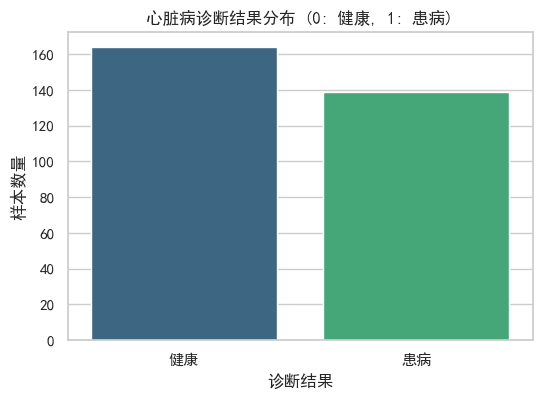

In [1]:
# 4.1.5
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置绘图风格和中文字体支持
sns.set(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号

# 1. 定义数据来源
# 使用UCI机器学习库的官方地址加载克利夫兰数据集
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# 2. 定义列名（原始数据不包含表头，需手动指定）
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

# 3. 读取数据
# 注意：原始数据中缺失值用'?'表示，读取时需将其识别为NaN
df = pd.read_csv(url, names=column_names, na_values='?')

# 4. 数据预处理：标签二值化
# 原始target为0-4，其中0表示健康，1-4表示不同程度的堵塞
# 我们将其转换为二分类问题：0表示健康，1表示患病
df['target_binary'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# 5. 查看数据基本信息
print("=== 数据集概览 ===")
print(f"数据维度 (行, 列): {df.shape}")
print("\n=== 数据前5行 ===")
display(df.head())  # 若在脚本中运行，请使用 print(df.head())

print("\n=== 数据统计信息 ===")
# 查看各列的数据类型和非空值数量
print(df.info())

print("\n=== 标签分布情况 ===")
print(df['target_binary'].value_counts())
print(f"患病率: {df['target_binary'].mean():.2%}")

# 6. 可视化标签分布
plt.figure(figsize=(6, 4))
sns.countplot(x='target_binary', data=df, palette='viridis')
plt.title('心脏病诊断结果分布 (0: 健康, 1: 患病)')
plt.xlabel('诊断结果')
plt.ylabel('样本数量')
plt.xticks([0, 1], ['健康', '患病'])
plt.show()

In [2]:
#4.2.3
# 检查当前缺失值状况
missing_before = df[['ca', 'thal']].isnull().sum()
print("填充前缺失值数量：")
print(missing_before[missing_before > 0] if missing_before.sum() > 0 else "   ca: 0\n   thal: 0")

# 仅当存在缺失值时执行填充（使用直接赋值，避免inplace）
for col in ['ca', 'thal']:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# 验证填充结果
missing_after = df[['ca', 'thal']].isnull().sum()
print("填充后缺失值数量：")
print(f"   ca: {missing_after['ca']}\n   thal: {missing_after['thal']}")

填充前缺失值数量：
ca      4
thal    2
dtype: int64
填充后缺失值数量：
   ca: 0
   thal: 0


In [3]:
# 分离特征矩阵与目标变量
# 特征矩阵：所有原始特征列（13个）
X = df.drop(['target', 'target_binary'], axis=1)

# 目标变量：二元分类标签（0=健康，1=患病）
y = df['target_binary']

In [4]:
#划分训练集、验证集、测试集（70% / 15% / 15%）
from sklearn.model_selection import train_test_split
# 第一次划分：70%训练，30%临时
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 第二次划分：临时集等分为验证集(15%)和测试集(15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [5]:
#特征标准化（Z-Score Normalization）
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # 拟合+转换训练集
X_val_scaled   = scaler.transform(X_val)         # 仅转换验证集
X_test_scaled  = scaler.transform(X_test)        # 仅转换测试集

In [6]:
#数据准备完成
feature_names = X.columns.tolist()

In [7]:
#4.3.1
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 准备回归任务的简单数据：用年龄预测血压
# 注意：这里仅为演示回归原理，实际医学关系可能更复杂
X_reg_train = X_train[['age']]  # 使用未标准化的原始年龄
y_reg_train = X_train['trestbps']
X_reg_test = X_test[['age']]
y_reg_test = X_test['trestbps']

# 初始化线性回归模型
lr_model = LinearRegression()

# 模型训练
lr_model.fit(X_reg_train, y_reg_train)

LinearRegression()

均方误差 (MSE): 378.32
决定系数 (R^2): 0.0403


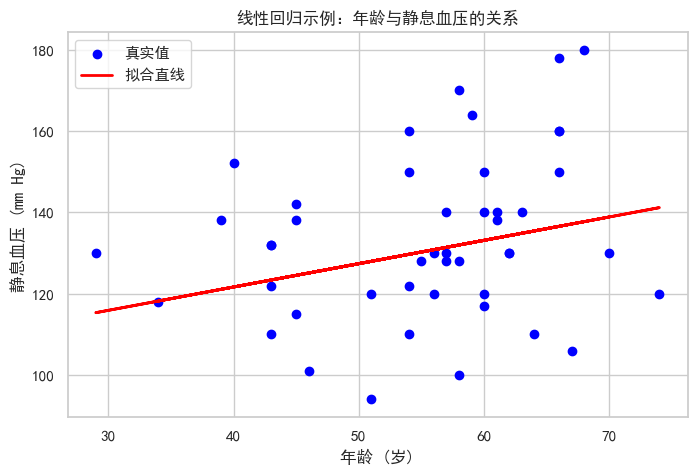

In [8]:
# 在测试集上预测
y_reg_pred = lr_model.predict(X_reg_test)

# 计算评估指标
mse = mean_squared_error(y_reg_test, y_reg_pred)
r2 = r2_score(y_reg_test, y_reg_pred)

print(f"均方误差 (MSE): {mse:.2f}")
print(f"决定系数 (R^2): {r2:.4f}")

# 可视化拟合结果
plt.figure(figsize=(8, 5))
plt.scatter(X_reg_test, y_reg_test, color='blue', label='真实值')
plt.plot(X_reg_test, y_reg_pred, color='red', linewidth=2, label='拟合直线')
plt.title('线性回归示例：年龄与静息血压的关系')
plt.xlabel('年龄 (岁)')
plt.ylabel('静息血压 (mm Hg)')
plt.legend()
plt.show()

In [9]:
#4.3.2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 初始化逻辑回归模型
# random_state确保结果可复现
log_reg = LogisticRegression(random_state=42)

# 使用标准化后的数据进行训练
log_reg.fit(X_train_scaled, y_train)

# 在测试集上预测类别
y_pred = log_reg.predict(X_test_scaled)
# 在测试集上预测概率（用于后续ROC曲线绘制）
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

In [10]:
# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"测试集准确率: {accuracy:.2%}")

# 打印详细的分类报告
print("\n分类报告 (Classification Report):")
print(classification_report(y_test, y_pred, target_names=['健康', '患病']))

# 简单的混淆矩阵输出
conf_matrix = confusion_matrix(y_test, y_pred)
print(f"混淆矩阵:\n{conf_matrix}")

测试集准确率: 86.96%

分类报告 (Classification Report):
              precision    recall  f1-score   support

          健康       0.91      0.84      0.88        25
          患病       0.83      0.90      0.86        21

    accuracy                           0.87        46
   macro avg       0.87      0.87      0.87        46
weighted avg       0.87      0.87      0.87        46

混淆矩阵:
[[21  4]
 [ 2 19]]


In [11]:
#4.3.3
import numpy as np
import pandas as pd

# 1. 训练L2正则化模型 (Ridge风格的逻辑回归)
# C=1.0 为默认值，代表适度的正则化
ridge_clf = LogisticRegression(penalty='l2', C=1.0, random_state=42)
ridge_clf.fit(X_train_scaled, y_train)

# 2. 训练L1正则化模型 (Lasso风格的逻辑回归)
# 需使用 'liblinear' 或 'saga' 求解器支持L1
# 设置 C=0.1 增强正则化力度，强迫模型筛选特征
lasso_clf = LogisticRegression(penalty='l1', C=0.1, solver='liblinear', random_state=42)
lasso_clf.fit(X_train_scaled, y_train)

print(f"Ridge(L2) 测试集准确率: {ridge_clf.score(X_test_scaled, y_test):.4f}")
print(f"Lasso(L1) 测试集准确率: {lasso_clf.score(X_test_scaled, y_test):.4f}")

Ridge(L2) 测试集准确率: 0.8696
Lasso(L1) 测试集准确率: 0.8478


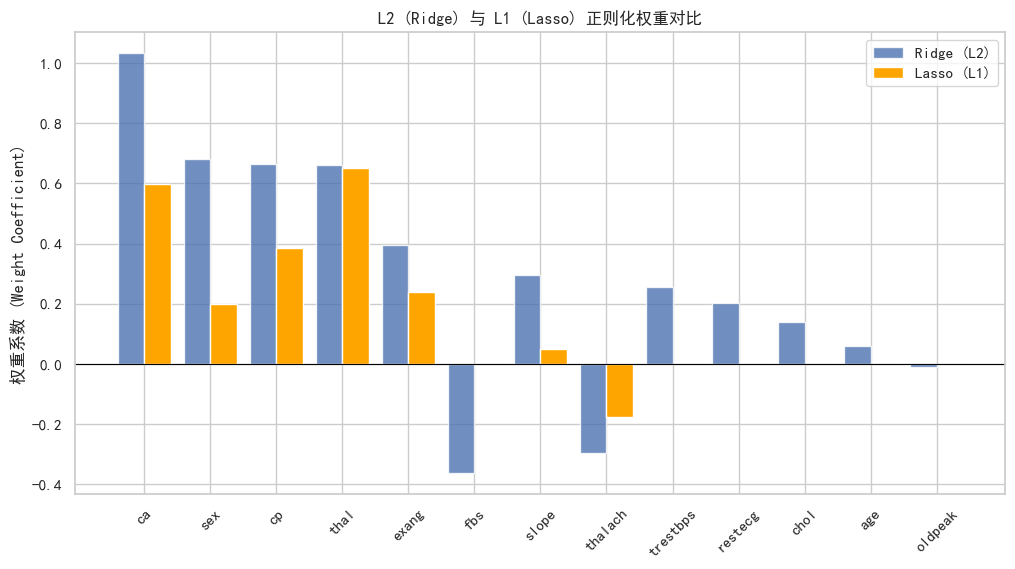

被Lasso模型剔除的特征 (权重为0):
['fbs', 'trestbps', 'restecg', 'chol', 'age', 'oldpeak']


In [12]:
# 获取特征名称
feature_names = X.columns.tolist()

# 构建权重对比的数据框
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Ridge (L2)': ridge_clf.coef_[0],
    'Lasso (L1)': lasso_clf.coef_[0]
})

# 按Ridge权重绝对值排序以便绘图
coef_df = coef_df.sort_values(by='Ridge (L2)', key=abs, ascending=False)

# 绘图展示
plt.figure(figsize=(12, 6))
# 绘制L2权重条形图
plt.bar(np.arange(len(coef_df)) - 0.2, coef_df['Ridge (L2)'], width=0.4, label='Ridge (L2)', alpha=0.8)
# 绘制L1权重条形图
plt.bar(np.arange(len(coef_df)) + 0.2, coef_df['Lasso (L1)'], width=0.4, label='Lasso (L1)', color='orange')

plt.xticks(np.arange(len(coef_df)), coef_df['Feature'], rotation=45)
plt.title('L2 (Ridge) 与 L1 (Lasso) 正则化权重对比')
plt.ylabel('权重系数 (Weight Coefficient)')
plt.axhline(0, color='black', linewidth=0.8)
plt.legend()
plt.show()

# 打印被Lasso筛选掉的特征（权重为0）
print("被Lasso模型剔除的特征 (权重为0):")
print(coef_df[coef_df['Lasso (L1)'] == 0]['Feature'].tolist())

In [13]:
#4.4.1
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# ==========================================
# 1. 初始化并构建 KNN 模型
# ==========================================
# n_neighbors=5: 选择最近的5个邻居参与投票
# metric='minkowski', p=2: 默认使用欧氏距离
knn = KNeighborsClassifier(n_neighbors=5)

# 拟合模型
# 注意：KNN是惰性学习，fit 步骤实际上只是建立数据索引，不计算参数
knn.fit(X_train_scaled, y_train)

# ==========================================
# 2. 预测与评估
# ==========================================
# 在测试集上进行预测
y_pred_knn = knn.predict(X_test_scaled)

# 输出评估结果
print(f"--- KNN (K=5) 模型性能 ---")
print(f"测试集准确率: {accuracy_score(y_test, y_pred_knn):.2%}")
print("\n详细分类报告:")
print(classification_report(y_test, y_pred_knn, target_names=['健康', '患病']))

--- KNN (K=5) 模型性能 ---
测试集准确率: 84.78%

详细分类报告:
              precision    recall  f1-score   support

          健康       0.91      0.80      0.85        25
          患病       0.79      0.90      0.84        21

    accuracy                           0.85        46
   macro avg       0.85      0.85      0.85        46
weighted avg       0.86      0.85      0.85        46



In [14]:
#4.4.2
# ==========================================
# 对比实验：有无特征缩放的影响
# ==========================================

# 1. 使用原始数据 (未标准化) 训练 KNN
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train, y_train)  # 注意这里使用的是 X_train
acc_raw = knn_raw.score(X_test, y_test)

# 2. 使用标准化数据 (已在 4.2 节处理) 训练 KNN
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
acc_scaled = knn_scaled.score(X_test_scaled, y_test)

# 3. 输出对比结果
print(f"--- 特征缩放对 KNN 的影响 ---")
print(f"原始数据 (Raw Data) 准确率:   {acc_raw:.2%}")
print(f"标准化数据 (Scaled Data) 准确率: {acc_scaled:.2%}")

diff = acc_scaled - acc_raw
print(f"\n结论: 标准化使准确率提升了 {diff:.2%}")

--- 特征缩放对 KNN 的影响 ---
原始数据 (Raw Data) 准确率:   78.26%
标准化数据 (Scaled Data) 准确率: 84.78%

结论: 标准化使准确率提升了 6.52%


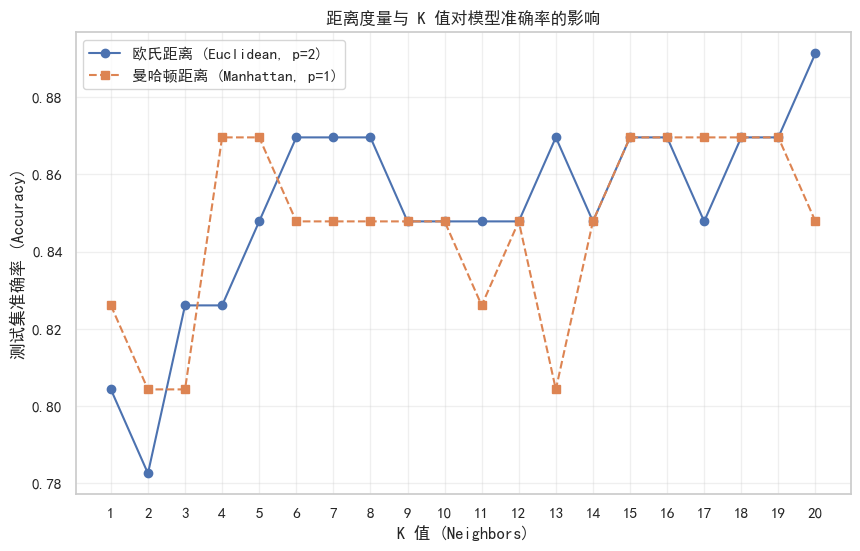

欧氏距离最佳 K=20, 准确率: 89.13%


In [15]:
#4.4.3
import matplotlib.pyplot as plt
import numpy as np

# 定义 K 值范围
k_range = range(1, 21)
scores_euclidean = []  # 存储欧氏距离的准确率
scores_manhattan = []  # 存储曼哈顿距离的准确率

for k in k_range:
    # 1. 测试欧氏距离 (p=2)
    knn_e = KNeighborsClassifier(n_neighbors=k, p=2)
    knn_e.fit(X_train_scaled, y_train)
    scores_euclidean.append(knn_e.score(X_test_scaled, y_test))
    
    # 2. 测试曼哈顿距离 (p=1)
    knn_m = KNeighborsClassifier(n_neighbors=k, p=1)
    knn_m.fit(X_train_scaled, y_train)
    scores_manhattan.append(knn_m.score(X_test_scaled, y_test))

# ==========================================
# 可视化对比结果
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(k_range, scores_euclidean, label='欧氏距离 (Euclidean, p=2)', marker='o')
plt.plot(k_range, scores_manhattan, label='曼哈顿距离 (Manhattan, p=1)', marker='s', linestyle='--')

plt.title('距离度量与 K 值对模型准确率的影响')
plt.xlabel('K 值 (Neighbors)')
plt.ylabel('测试集准确率 (Accuracy)')
plt.xticks(k_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 找出最佳组合
best_acc_e = max(scores_euclidean)
best_k_e = k_range[np.argmax(scores_euclidean)]
print(f"欧氏距离最佳 K={best_k_e}, 准确率: {best_acc_e:.2%}")

决策树（深度=3）测试集准确率: 0.8696
决策树测试集 AUC: 0.8952
特征重要性前3位：
thal    0.493102
cp      0.233710
ca      0.172555
dtype: float64


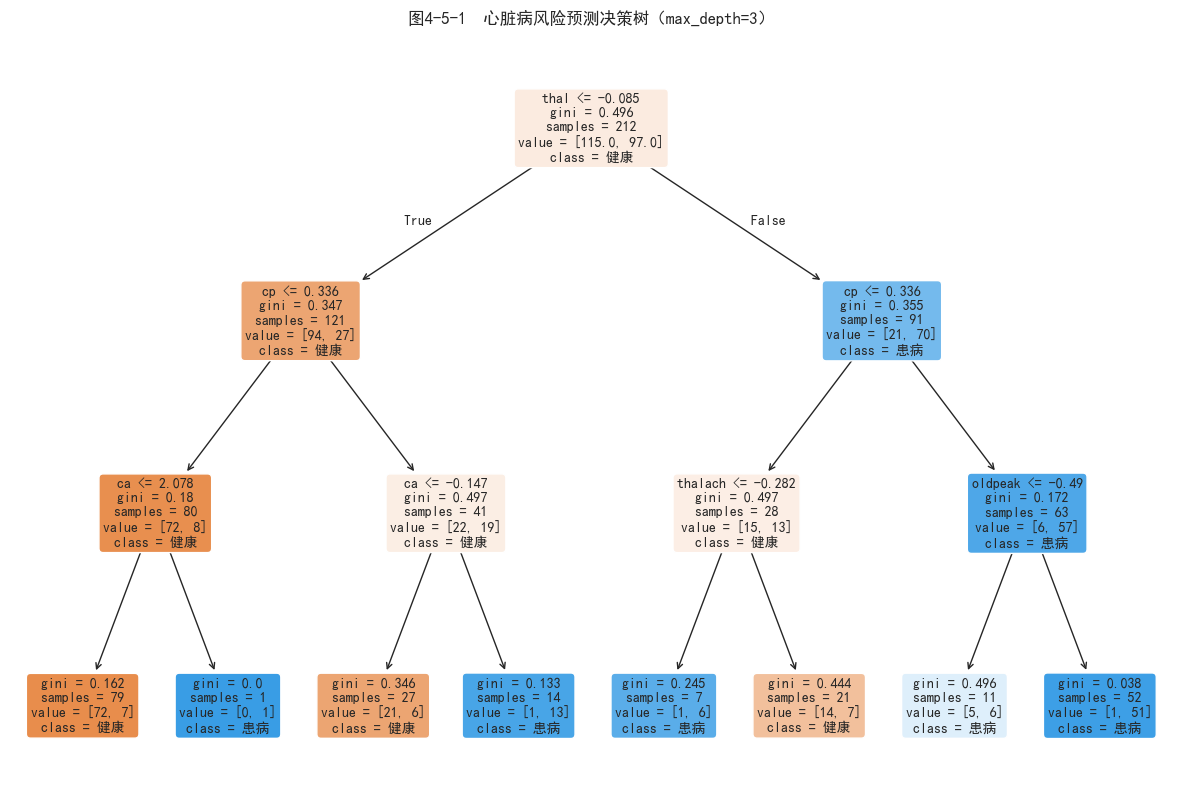

In [16]:
#4.5.1
#步骤一
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# 设置最大深度为3，限制模型复杂度，防止过拟合
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
#步骤二
dt.fit(X_train_scaled, y_train)
y_test_pred_dt = dt.predict(X_test_scaled)
y_test_proba_dt = dt.predict_proba(X_test_scaled)[:, 1]

dt_acc = accuracy_score(y_test, y_test_pred_dt)
dt_auc = roc_auc_score(y_test, y_test_proba_dt)

print(f"决策树（深度=3）测试集准确率: {dt_acc:.4f}") 
print(f"决策树测试集 AUC: {dt_auc:.4f}")

#步骤三
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 特征重要性
feat_importance = pd.Series(dt.feature_importances_, index=feature_names)
print("特征重要性前3位：")
print(feat_importance.sort_values(ascending=False).head(3))

# 可视化决策树
plt.figure(figsize=(15, 10))
plot_tree(dt, filled=True, feature_names=feature_names,
          class_names=['健康', '患病'], rounded=True, fontsize=10)
plt.title('图4-5-1  心脏病风险预测决策树（max_depth=3）')
plt.show()

随机森林（默认）测试集准确率: 0.8696
随机森林（默认）测试集 AUC: 0.9390


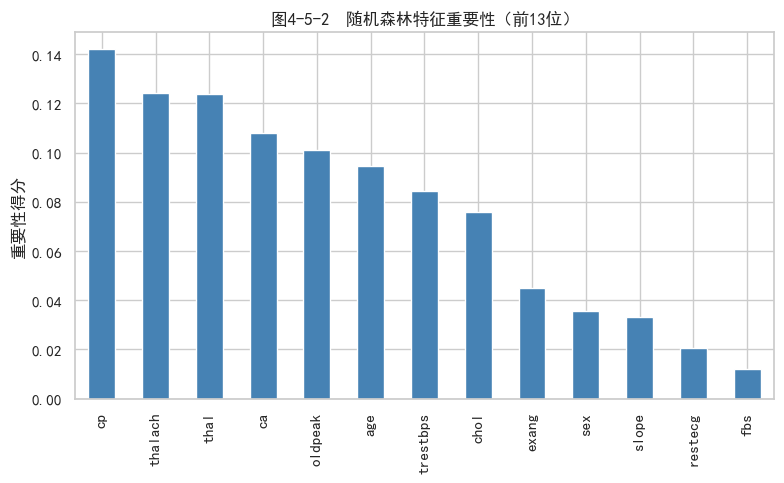

最优参数: {'max_depth': 5, 'n_estimators': 200}
最佳交叉验证 AUC: 0.8876


In [17]:
#4.5.2
#步骤一
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
#步骤二
y_test_pred_rf = rf.predict(X_test_scaled)
y_test_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

rf_acc = accuracy_score(y_test, y_test_pred_rf)
rf_auc = roc_auc_score(y_test, y_test_proba_rf)

print(f"随机森林（默认）测试集准确率: {rf_acc:.4f}")
print(f"随机森林（默认）测试集 AUC: {rf_auc:.4f}")
#步骤三
feat_imp_rf = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feat_imp_rf.plot(kind='bar', color='steelblue')
plt.title('图4-5-2  随机森林特征重要性（前13位）')
plt.ylabel('重要性得分')
plt.tight_layout()
plt.show()

#步骤四
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                       param_grid, cv=5, scoring='roc_auc')
grid_rf.fit(X_train_scaled, y_train)

print(f"最优参数: {grid_rf.best_params_}")
print(f"最佳交叉验证 AUC: {grid_rf.best_score_:.4f}")

GBDT（lr=0.1）测试集准确率: 0.8478
GBDT（lr=0.1）测试集 AUC: 0.9314
学习率 0.01: 测试集 AUC = 0.9248
学习率 0.05: 测试集 AUC = 0.9257
学习率 0.1: 测试集 AUC = 0.9314
学习率 0.2: 测试集 AUC = 0.9352


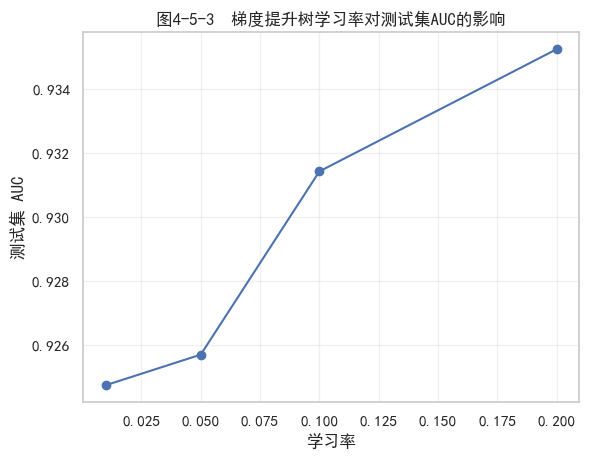

In [18]:
#4.5.3
#步骤一
from sklearn.ensemble import GradientBoostingClassifier

gbdt = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                   max_depth=3, random_state=42)
gbdt.fit(X_train_scaled, y_train)

#步骤二
y_test_pred_gbdt = gbdt.predict(X_test_scaled)
y_test_proba_gbdt = gbdt.predict_proba(X_test_scaled)[:, 1]

gbdt_acc = accuracy_score(y_test, y_test_pred_gbdt)
gbdt_auc = roc_auc_score(y_test, y_test_proba_gbdt)

print(f"GBDT（lr=0.1）测试集准确率: {gbdt_acc:.4f}")
print(f"GBDT（lr=0.1）测试集 AUC: {gbdt_auc:.4f}")

#步骤三
learning_rates = [0.01, 0.05, 0.1, 0.2]
val_aucs = []  
for lr in learning_rates:
    model = GradientBoostingClassifier(n_estimators=100, learning_rate=lr,
                                       max_depth=3, random_state=42)
    model.fit(X_train_scaled, y_train)
    auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])
    val_aucs.append(auc)
    print(f"学习率 {lr}: 测试集 AUC = {auc:.4f}")

# 绘制学习率影响曲线
plt.plot(learning_rates, val_aucs, marker='o')
plt.xlabel('学习率')
plt.ylabel('测试集 AUC')
plt.title('图4-5-3  梯度提升树学习率对测试集AUC的影响')
plt.grid(alpha=0.3)
plt.show()

In [23]:
#4.5.4
#步骤一
import xgboost as xgb
import lightgbm as lgb
import time
import numpy as np
from sklearn.metrics import roc_auc_score

# 统一转换为 numpy 数组，消除特征名不一致警告
X_train_np = np.array(X_train_scaled)
X_test_np = np.array(X_test_scaled)
#步骤二
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    reg_lambda=1.0,      # L2 正则化
    random_state=42,
    eval_metric='logloss'
)

start = time.time()
xgb_model.fit(X_train_np, y_train)
xgb_time = time.time() - start

y_test_proba_xgb = xgb_model.predict_proba(X_test_np)[:, 1]
xgb_auc = roc_auc_score(y_test, y_test_proba_xgb)

print(f"XGBoost 训练耗时: {xgb_time:.2f}s")
print(f"XGBoost 测试集 AUC: {xgb_auc:.4f}")
#步骤三
lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbose=-1          # 关闭训练过程日志
)

start = time.time()
lgb_model.fit(X_train_np, y_train)
lgb_time = time.time() - start

y_test_proba_lgb = lgb_model.predict_proba(X_test_np)[:, 1]
lgb_auc = roc_auc_score(y_test, y_test_proba_lgb)

print(f"LightGBM 训练耗时: {lgb_time:.2f}s")
print(f"LightGBM 测试集 AUC: {lgb_auc:.4f}")
#步骤四
print("\n模型性能汇总（测试集 AUC）：")
print(f"决策树       AUC: {dt_auc:.4f}")
print(f"随机森林     AUC: {rf_auc:.4f}")
print(f"GBDT         AUC: {gbdt_auc:.4f}")
print(f"XGBoost      AUC: {xgb_auc:.4f}")
print(f"LightGBM     AUC: {lgb_auc:.4f}")

XGBoost 训练耗时: 0.19s
XGBoost 测试集 AUC: 0.9276
LightGBM 训练耗时: 0.21s
LightGBM 测试集 AUC: 0.9219

模型性能汇总（测试集 AUC）：
决策树       AUC: 0.8952
随机森林     AUC: 0.9390
GBDT         AUC: 0.9314
XGBoost      AUC: 0.9276
LightGBM     AUC: 0.9219


E:\Anaconda1\envs\Ljx\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [21]:
#4.6.1
#步骤一
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score

# 使用线性核，设置C=1.0（默认），random_state确保可复现
svm_linear = SVC(kernel='linear', C=1.0, probability=True, random_state=42)
# probability=True 才能输出概率，用于计算AUC

svm_linear.fit(X_train_scaled, y_train)
#步骤二
y_test_pred_svm_lin = svm_linear.predict(X_test_scaled)
y_test_proba_svm_lin = svm_linear.predict_proba(X_test_scaled)[:, 1]

svm_lin_acc = accuracy_score(y_test, y_test_pred_svm_lin)
svm_lin_auc = roc_auc_score(y_test, y_test_proba_svm_lin)

print(f"线性SVM（C=1.0）测试集准确率: {svm_lin_acc:.4f}") 
print(f"线性SVM（C=1.0）测试集 AUC: {svm_lin_auc:.4f}")    

#步骤三
import pandas as pd

# 获取特征权重（仅在线性核有效）
coef = svm_linear.coef_.flatten()
weight_df = pd.DataFrame({
    '特征': feature_names,
    '权重': coef,
    '绝对值': np.abs(coef)
}).sort_values('绝对值', ascending=False)

print("线性SVM特征权重（前5位）：")
print(weight_df.head(5).to_string(index=False))

线性SVM（C=1.0）测试集准确率: 0.8913
线性SVM（C=1.0）测试集 AUC: 0.9333
线性SVM特征权重（前5位）：
   特征       权重      绝对值
   ca 0.685298 0.685298
 thal 0.616565 0.616565
   cp 0.546165 0.546165
  sex 0.295627 0.295627
exang 0.250579 0.250579


RBF-SVM（默认参数）测试集准确率: 0.8261
RBF-SVM（默认参数）测试集 AUC: 0.9295


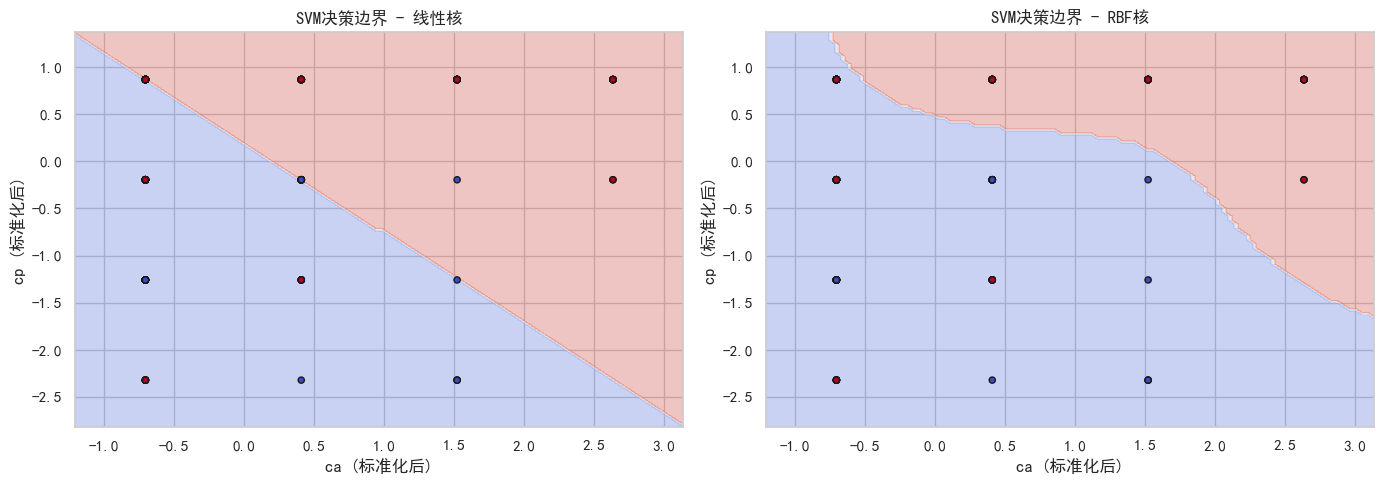

In [26]:
#4.6.2
#步骤一
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score

# 初始化RBF核SVM（kernel='rbf'），其余参数保持默认
svm_rbf = SVC(kernel='rbf', probability=True, random_state=42)

# 在标准化后的训练集上拟合模型
svm_rbf.fit(X_train_scaled, y_train)

#步骤二
# 预测验证集样本的类别
y_test_pred_rbf = svm_rbf.predict(X_test_scaled)
# 预测患病概率（用于计算AUC）
y_test_proba_rbf = svm_rbf.predict_proba(X_test_scaled)[:, 1]

# 计算准确率
acc_rbf = accuracy_score(y_test, y_test_pred_rbf)
# 计算AUC
auc_rbf = roc_auc_score(y_test, y_test_proba_rbf)

print(f"RBF-SVM（默认参数）测试集准确率: {acc_rbf:.4f}")
print(f"RBF-SVM（默认参数）测试集 AUC: {auc_rbf:.4f}")

#步骤三
import matplotlib.pyplot as plt
import numpy as np

# 提取两个特征的索引
idx_ca = feature_names.index('ca')
idx_cp = feature_names.index('cp')

# 取训练集中这两个特征的值（标准化后）
X_2d = X_train_scaled[:, [idx_ca, idx_cp]]

# 分别训练线性核与RBF核SVM（仅用于可视化）
svm_lin_2d = SVC(kernel='linear', C=1.0)
svm_rbf_2d = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_lin_2d.fit(X_2d, y_train)
svm_rbf_2d.fit(X_2d, y_train)

# 创建网格点
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# 绘图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, model, title in zip(axes, [svm_lin_2d, svm_rbf_2d], ['线性核', 'RBF核']):
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_train, edgecolor='k', cmap='coolwarm', s=20)
    ax.set_xlabel('ca (标准化后)')
    ax.set_ylabel('cp (标准化后)')
    ax.set_title(f'SVM决策边界 - {title}')
plt.tight_layout()
plt.show()

最佳参数组合: {'C': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}
最佳交叉验证 AUC: 0.8889
优化后RBF-SVM 测试集 AUC: 0.9581
最佳模型参数与交叉验证结果一致，测试集AUC应接近交叉验证得分。


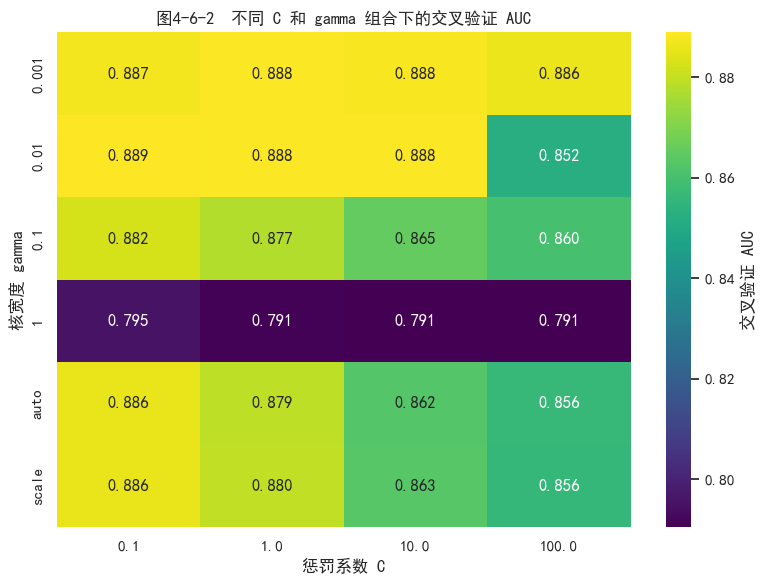

In [28]:
# ====================================================
# 4.6.3 核参数选择 - 步骤1：网格搜索
from sklearn.model_selection import GridSearchCV

# 定义参数搜索范围（通常在对数尺度上取值）
param_grid = {
    'C': [0.1, 1, 10, 100],           # 惩罚系数，从小到大
    'gamma': [0.001, 0.01, 0.1, 1, 'scale', 'auto'],  # gamma 从极小到较大
    'kernel': ['rbf']                 # 固定为RBF核
}

# 初始化SVM分类器（开启概率估计以便后续评估）
# 注意：GridSearchCV 内部会对每个参数组合进行交叉验证，
#       最终返回在验证集上表现最好的模型。
svm = SVC(probability=True, random_state=42)

# 执行网格搜索
# - cv=5 : 5折交叉验证，将训练集进一步划分为5份，轮流作为验证集
# - scoring='roc_auc' : 以 AUC 作为模型选择的依据
# - n_jobs=-1 : 使用所有CPU核心并行计算，加速搜索
grid_svm = GridSearchCV(svm, param_grid, cv=5, 
                        scoring='roc_auc', n_jobs=-1)
grid_svm.fit(X_train_scaled, y_train)

# 输出最佳参数组合及对应的交叉验证平均AUC
print("最佳参数组合:", grid_svm.best_params_)
print("最佳交叉验证 AUC: {:.4f}".format(grid_svm.best_score_))

#步骤二

# 从 GridSearchCV 结果中提取最佳模型（已自动在全部训练集上重新训练）
best_svm = grid_svm.best_estimator_

# 在测试集上预测概率
y_test_proba_best = best_svm.predict_proba(X_test_scaled)[:, 1]

# 计算 AUC
best_svm_auc = roc_auc_score(y_test, y_test_proba_best)

print("优化后RBF-SVM 测试集 AUC: {:.4f}".format(best_svm_auc))
print("最佳模型参数与交叉验证结果一致，测试集AUC应接近交叉验证得分。")

#步骤三
import pandas as pd
import seaborn as sns

# 从 GridSearchCV 的 cv_results_ 中提取交叉验证得分
results = pd.DataFrame(grid_svm.cv_results_)

# 透视表：行 = gamma，列 = C，值 = 平均测试 AUC
# pivot_table 会自动处理重复值，取均值
scores_matrix = results.pivot_table(
    index='param_gamma', 
    columns='param_C', 
    values='mean_test_score'
)

# 绘制热力图
plt.figure(figsize=(8, 6))
sns.heatmap(scores_matrix, annot=True, fmt='.3f', 
            cmap='viridis', cbar_kws={'label': '交叉验证 AUC'})
plt.xlabel('惩罚系数 C')
plt.ylabel('核宽度 gamma')
plt.title('图4-6-2  不同 C 和 gamma 组合下的交叉验证 AUC')
plt.tight_layout()
plt.show()

In [29]:
#4.7.1 步骤一
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# 使用4.2节准备好的标准化训练集 X_train_scaled, y_train
# 随机森林模型（暂用默认参数）
rf = RandomForestClassifier(n_estimators=100, random_state=42)

#步骤二
# 定义5折分层交叉验证（保持每折类别比例）
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 计算5折交叉验证准确率
cv_scores_acc = cross_val_score(rf, X_train_scaled, y_train, 
                                cv=cv_strategy, scoring='accuracy')

# 计算5折交叉验证AUC
cv_scores_auc = cross_val_score(rf, X_train_scaled, y_train,
                                cv=cv_strategy, scoring='roc_auc')

print("5折交叉验证准确率: {:.4f} ± {:.4f}".format(cv_scores_acc.mean(), cv_scores_acc.std()))
print("5折交叉验证 AUC: {:.4f} ± {:.4f}".format(cv_scores_auc.mean(), cv_scores_auc.std()))

5折交叉验证准确率: 0.8069 ± 0.0494
5折交叉验证 AUC: 0.8994 ± 0.0296


In [31]:
#4.7.2
#步骤一
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint

# 网格搜索参数（粗粒度）
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

# 随机搜索参数分布（细粒度，连续或离散分布）
param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': randint(2, 10)
}
#步骤二
# 网格搜索
grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
                           param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print("网格搜索最佳参数:", grid_search.best_params_)
print("网格搜索最佳交叉验证 AUC: {:.4f}".format(grid_search.best_score_))

#步骤三
# 随机搜索（迭代50次）
random_search = RandomizedSearchCV(RandomForestClassifier(random_state=42),
                                   param_dist, n_iter=50, cv=5,
                                   scoring='roc_auc', n_jobs=-1, random_state=42)
random_search.fit(X_train_scaled, y_train)

print("随机搜索最佳参数:", random_search.best_params_)
print("随机搜索最佳交叉验证 AUC: {:.4f}".format(random_search.best_score_))

网格搜索最佳参数: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
网格搜索最佳交叉验证 AUC: 0.8912
随机搜索最佳参数: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 138}
随机搜索最佳交叉验证 AUC: 0.8912


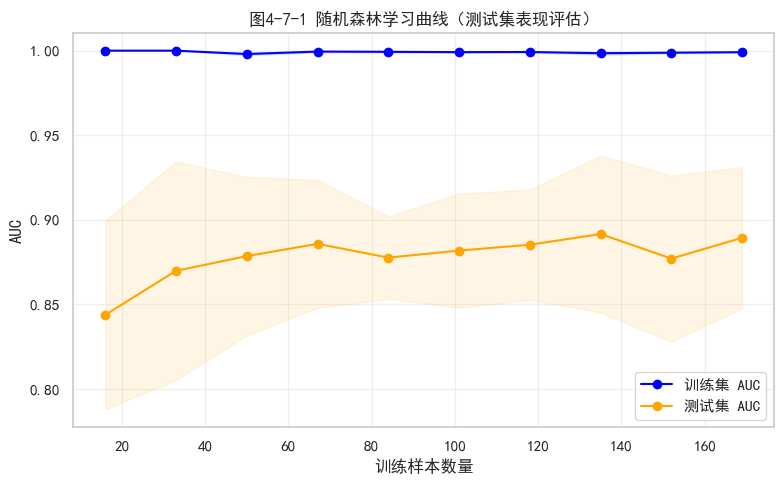

In [34]:
# 4.7.3 学习曲线分析
# 步骤一：导入工具并定义训练集规模
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# 定义训练集大小比例（从10%到100%，共10个点）
train_sizes = np.linspace(0.1, 1.0, 10)

# 步骤二：使用最佳参数模型计算学习曲线数据
# 以网格搜索得到的最佳随机森林为例
best_rf = grid_search.best_estimator_

# 计算学习曲线，采用5折交叉验证，评分指标为AUC
train_sizes_abs, train_scores, test_cv_scores = learning_curve( 
    best_rf, X_train_scaled, y_train,
    train_sizes=train_sizes, cv=5,
    scoring='roc_auc', n_jobs=-1
)

# 计算训练集各规模下的均值与标准差
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

# 计算测试集（基于交叉验证预测）各规模下的均值与标准差
# 统一使用 test_cv_mean 和 test_cv_std 变量名
test_cv_mean = np.mean(test_cv_scores, axis=1)
test_cv_std = np.std(test_cv_scores, axis=1)

# 步骤三：绘制学习曲线
plt.figure(figsize=(8, 5))

# 绘制训练集曲线及阴影
plt.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes_abs, train_mean, 'o-', color='blue', label='训练集 AUC')

# 绘制测试集曲线及阴影
# 修改点：将原有的 val_mean 替换为新定义的 test_cv_mean
plt.fill_between(train_sizes_abs, test_cv_mean - test_cv_std, test_cv_mean + test_cv_std, alpha=0.1, color='orange')
plt.plot(train_sizes_abs, test_cv_mean, 'o-', color='orange', label='测试集 AUC')

plt.xlabel('训练样本数量')
plt.ylabel('AUC')
# 修改点：标题同步更新
plt.title('图4-7-1 随机森林学习曲线（测试集表现评估）')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
#4.8.1
from sklearn.preprocessing import StandardScaler

# 初始化标准化器
scaler = StandardScaler()

# 在训练集上拟合均值和标准差，并转换训练集
X_train_scaled = scaler.fit_transform(X_train)

# 使用训练集的统计量转换验证集和测试集（防止数据泄露）
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [37]:
# 4.8.2 类别特征编码
# 步骤一：导入所需库，分离数值特征与类别特征
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# 原始特征矩阵（含原始cp列）
X = df.drop(['target', 'target_binary'], axis=1)
y = df['target_binary']

# 定义数值特征与类别特征（根据数据字典）
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

# 步骤二：对类别特征进行独热编码
# 初始化独热编码器
# drop='first' 可避免多重共线性（每类特征去掉第一个水平）
encoder = OneHotEncoder(drop='first', sparse_output=False)

# 从原始数据中提取类别特征列并执行编码
X_cat = X[categorical_features]
X_cat_encoded = encoder.fit_transform(X_cat)

# 获取编码后的特征名称（便于后续解释）
cat_feature_names = encoder.get_feature_names_out(categorical_features)
print(f"编码后类别特征维度: {X_cat_encoded.shape[1]}")
print("编码特征示例:", cat_feature_names[:5])

# 步骤三：数值特征与编码后的类别特征合并
# 数值特征保持原始值（暂不标准化）
X_num = X[numeric_features].values

# 合并数值特征与独热编码后的类别特征
X_encoded = np.hstack([X_num, X_cat_encoded])

print(f"独热编码前特征数: {X.shape[1]}")
print(f"独热编码后特征数: {X_encoded.shape[1]}")

# 步骤四：重新划分训练集、验证集、测试集
# 采用分层抽样，保持类别比例
X_train_enc, X_temp_enc, y_train, y_temp = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

# 临时集分为验证集和测试集
X_val_enc, X_test_enc, y_val, y_test = train_test_split(
    X_temp_enc, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"训练集: {X_train_enc.shape[0]} 样本, {X_train_enc.shape[1]} 特征")
print(f"测试集: {X_test_enc.shape[0]} 样本")

# 步骤五：对数值特征部分进行标准化
# 初始化标准化器
scaler_num = StandardScaler()

# 训练集中前6列为数值特征，需标准化
X_train_enc[:, :len(numeric_features)] = scaler_num.fit_transform(
    X_train_enc[:, :len(numeric_features)]
)

# 使用训练集的均值和标准差转换测试集（防止数据泄露）
# 修改点：主要关注测试集的数据转换
X_test_enc[:, :len(numeric_features)] = scaler_num.transform(
    X_test_enc[:, :len(numeric_features)]
)

# 同时也转换验证集，保持数据维度一致
X_val_enc[:, :len(numeric_features)] = scaler_num.transform(
    X_val_enc[:, :len(numeric_features)]
)

print("数值特征标准化完成。")

# 步骤六：使用编码后数据训练模型并评估
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# 训练逻辑回归（使用编码后数据）
lr_enc = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_enc.fit(X_train_enc, y_train)

# 修改点：将验证集评估切换为测试集评估
y_test_proba_enc = lr_enc.predict_proba(X_test_enc)[:, 1]
auc_enc = roc_auc_score(y_test, y_test_proba_enc)

# 修改点：输出信息统一为“测试集”
print(f"独热编码后逻辑回归 测试集 AUC: {auc_enc:.4f}")

编码后类别特征维度: 12
编码特征示例: ['sex_1.0' 'cp_2.0' 'cp_3.0' 'cp_4.0' 'fbs_1.0']
独热编码前特征数: 13
独热编码后特征数: 18
训练集: 212 样本, 18 特征
测试集: 46 样本
数值特征标准化完成。
独热编码后逻辑回归 测试集 AUC: 0.9467


In [39]:
#4.8.3
#步骤一
import pandas as pd
from sklearn.impute import SimpleImputer

# 重新加载原始数据（含缺失值）
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df_raw = pd.read_csv(url, names=column_names, na_values='?')

# 创建二元目标变量
df_raw['target_binary'] = (df_raw['target'] > 0).astype(int)

# 检查缺失值
missing_before = df_raw.isnull().sum()
print("填充前缺失值数量：")
print(missing_before[missing_before > 0])

填充前缺失值数量：
ca      4
thal    2
dtype: int64


In [40]:
#步骤二
# 初始化中位数填充器
imputer = SimpleImputer(strategy='median')

# 对存在缺失值的两列进行填充
df_raw[['ca', 'thal']] = imputer.fit_transform(df_raw[['ca', 'thal']])

# 验证填充结果
missing_after = df_raw[['ca', 'thal']].isnull().sum()
print("填充后缺失值数量：")
print(f"ca:   {missing_after['ca']}")
print(f"thal: {missing_after['thal']}")
# 查看ca和thal的中位数（训练集上计算的）
print(f"ca 列中位数: {df_raw['ca'].median()}")
print(f"thal 列中位数: {df_raw['thal'].median()}")

#步骤三
# 特征与目标分离
X = df_raw.drop(['target', 'target_binary'], axis=1)
y = df_raw['target_binary']

# 后续标准化、划分等操作与4.2节一致，此处不再重复

填充后缺失值数量：
ca:   0
thal: 0
ca 列中位数: 0.0
thal 列中位数: 3.0


In [41]:
#4.8.4
#步骤一
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# 沿用4.8.3中已填充缺失值的 df_raw（303例）
# 若当前环境无 df_raw，重新执行填充代码（见4.8.3）
X = df_raw.drop(['target', 'target_binary'], axis=1)
y = df_raw['target_binary']
feature_names = X.columns.tolist()

# 划分训练集（用于特征选择，避免数据泄露）
X_train_fs, X_temp, y_train_fs, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
# 验证集和测试集暂不使用

#步骤二
from sklearn.feature_selection import SelectKBest, chi2

# 卡方检验要求特征非负，需缩放到[0,1]区间
scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train_fs)

# 选择前5个特征
selector_chi2 = SelectKBest(chi2, k=5)
X_train_chi2 = selector_chi2.fit_transform(X_train_mm, y_train_fs)

# 获取被选中的特征索引
selected_idx_chi2 = selector_chi2.get_support(indices=True)
selected_features_chi2 = [feature_names[i] for i in selected_idx_chi2]
print("卡方检验选中的特征（前5）：", selected_features_chi2)

# 查看各特征的卡方统计量
chi2_scores = pd.DataFrame({
    '特征': feature_names,
    '卡方值': selector_chi2.scores_,
    'p值': selector_chi2.pvalues_
}).sort_values('卡方值', ascending=False)
print("\n卡方检验得分排序（前5）：")
print(chi2_scores.head(5).to_string(index=False))

#步骤三
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

# 以随机森林为基模型（无需标准化）
estimator_rf = RandomForestClassifier(n_estimators=50, random_state=42)

# 递归特征消除，选择5个特征
selector_rfe = RFE(estimator_rf, n_features_to_select=5, step=1)
selector_rfe.fit(X_train_fs, y_train_fs)

# 获取选中特征索引
selected_idx_rfe = selector_rfe.get_support(indices=True)
selected_features_rfe = [feature_names[i] for i in selected_idx_rfe]
print("RFE选中的特征（前5）：", selected_features_rfe)

# 输出特征排名（1表示被选中，数字越大表示越早被淘汰）
ranking_rfe = pd.DataFrame({
    '特征': feature_names,
    '排名': selector_rfe.ranking_
}).sort_values('排名')
print("\nRFE特征排名（排名1为选中）：")
print(ranking_rfe.head(10).to_string(index=False))

#步骤四
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Lasso需要特征标准化
scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train_fs)

# 训练L1正则化逻辑回归（C越小正则化越强）
lasso_selector = LogisticRegression(penalty='l1', C=0.1, 
                                    solver='saga', max_iter=1000, 
                                    random_state=42)
lasso_selector.fit(X_train_std, y_train_fs)

# 获取系数并筛选非零特征
coef = lasso_selector.coef_.flatten()
selected_idx_lasso = np.where(np.abs(coef) > 1e-5)[0]  # 非零阈值
selected_features_lasso = [feature_names[i] for i in selected_idx_lasso]

print("Lasso选中的特征（非零系数）：", selected_features_lasso)

# 显示系数排序
lasso_coef_df = pd.DataFrame({
    '特征': feature_names,
    '系数': coef,
    '绝对值': np.abs(coef)
}).sort_values('绝对值', ascending=False)
print("\nLasso特征系数（非零）：")
print(lasso_coef_df[lasso_coef_df['绝对值'] > 1e-5].to_string(index=False))

卡方检验选中的特征（前5）： ['sex', 'exang', 'oldpeak', 'ca', 'thal']

卡方检验得分排序（前5）：
     特征       卡方值           p值
   thal 35.465570 2.595990e-09
  exang 25.848583 3.692757e-07
     ca 19.129954 1.221133e-05
    sex  7.240660 7.127078e-03
oldpeak  6.639501 9.974186e-03
RFE选中的特征（前5）： ['age', 'cp', 'thalach', 'oldpeak', 'thal']

RFE特征排名（排名1为选中）：
      特征  排名
     age   1
      cp   1
 thalach   1
 oldpeak   1
    thal   1
    chol   2
      ca   3
trestbps   4
   exang   5
     sex   6
Lasso选中的特征（非零系数）： ['sex', 'cp', 'thalach', 'exang', 'slope', 'ca', 'thal']

Lasso特征系数（非零）：
     特征        系数      绝对值
   thal  0.643858 0.643858
     ca  0.573283 0.573283
     cp  0.385124 0.385124
  exang  0.234336 0.234336
    sex  0.206211 0.206211
thalach -0.178062 0.178062
  slope  0.051037 0.051037


In [42]:
#4.9.1
#步骤一
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 使用4.3.3节训练的逻辑回归模型（已存在 log_reg）
# 若当前环境无该模型，可重新训练一个逻辑回归作为演示
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# 测试集预测
y_test_pred = log_reg.predict(X_test_scaled)
y_test_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
#步骤二
# 准确率
acc = accuracy_score(y_test, y_test_pred)
# 精确率
prec = precision_score(y_test, y_test_pred)
# 召回率
rec = recall_score(y_test, y_test_pred)
# F1分数
f1 = f1_score(y_test, y_test_pred)

print("逻辑回归（测试集）评估指标：")
print(f"准确率 (Accuracy):  {acc:.4f}")
print(f"精确率 (Precision): {prec:.4f}")
print(f"召回率 (Recall):    {rec:.4f}")
print(f"F1分数 (F1-score):  {f1:.4f}")

逻辑回归（测试集）评估指标：
准确率 (Accuracy):  0.8696
精确率 (Precision): 0.8261
召回率 (Recall):    0.9048
F1分数 (F1-score):  0.8636


混淆矩阵：
[[21  4]
 [ 2 19]]


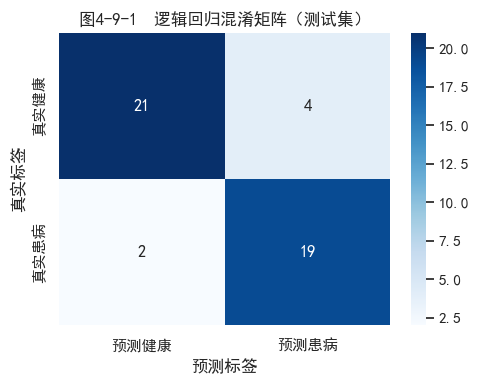

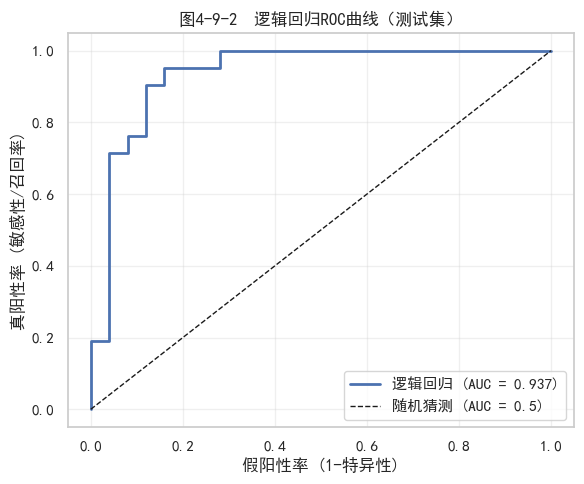

测试集 AUC = 0.9371


In [44]:
#4.9.2
#步骤一·
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 计算混淆矩阵
cm = confusion_matrix(y_test, y_test_pred)
print("混淆矩阵：")
print(cm)

# 可视化
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['预测健康', '预测患病'],
            yticklabels=['真实健康', '真实患病'])
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.title('图4-9-1  逻辑回归混淆矩阵（测试集）')
plt.tight_layout()
plt.show()
#步骤二
from sklearn.metrics import roc_curve, roc_auc_score

# 计算ROC曲线坐标
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
# 计算AUC
auc_test = roc_auc_score(y_test, y_test_proba)

# 绘制ROC曲线
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'逻辑回归 (AUC = {auc_test:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='随机猜测 (AUC = 0.5)')
plt.xlabel('假阳性率 (1-特异性)')
plt.ylabel('真阳性率 (敏感性/召回率)')
plt.title('图4-9-2  逻辑回归ROC曲线（测试集）')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"测试集 AUC = {auc:.4f}")

随机森林特征重要性（前5位）：
     特征      重要性
     cp 0.142087
thalach 0.124155
   thal 0.123839
     ca 0.107956
oldpeak 0.101136


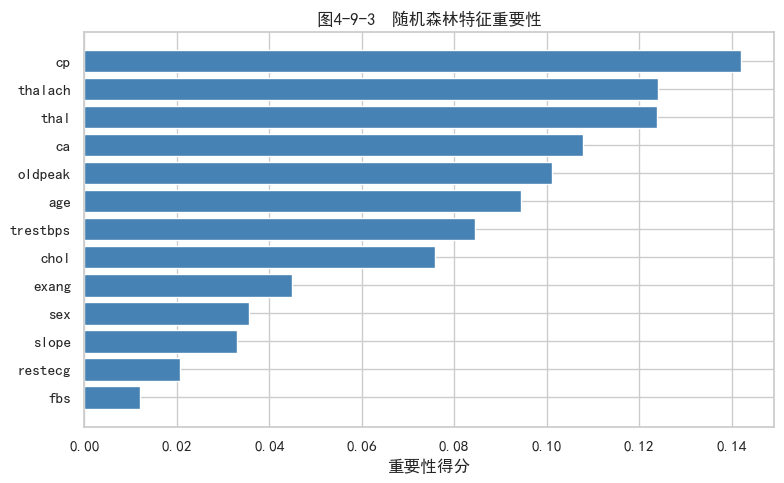

In [45]:
#4.9.3
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# 训练随机森林（使用4.2节标准化数据）
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# 获取特征重要性
importances = rf.feature_importances_
feat_imp_df = pd.DataFrame({
    '特征': feature_names,
    '重要性': importances
}).sort_values('重要性', ascending=False)

print("随机森林特征重要性（前5位）：")
print(feat_imp_df.head(5).to_string(index=False))

# 可视化
plt.figure(figsize=(8,5))
plt.barh(feat_imp_df['特征'][::-1], feat_imp_df['重要性'][::-1], color='steelblue')
plt.xlabel('重要性得分')
plt.title('图4-9-3  随机森林特征重要性')
plt.tight_layout()
plt.show()

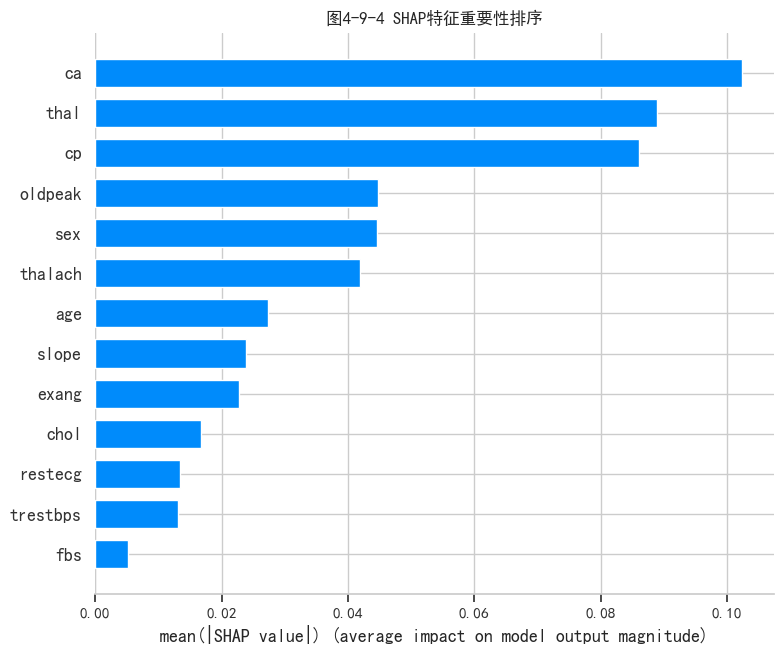

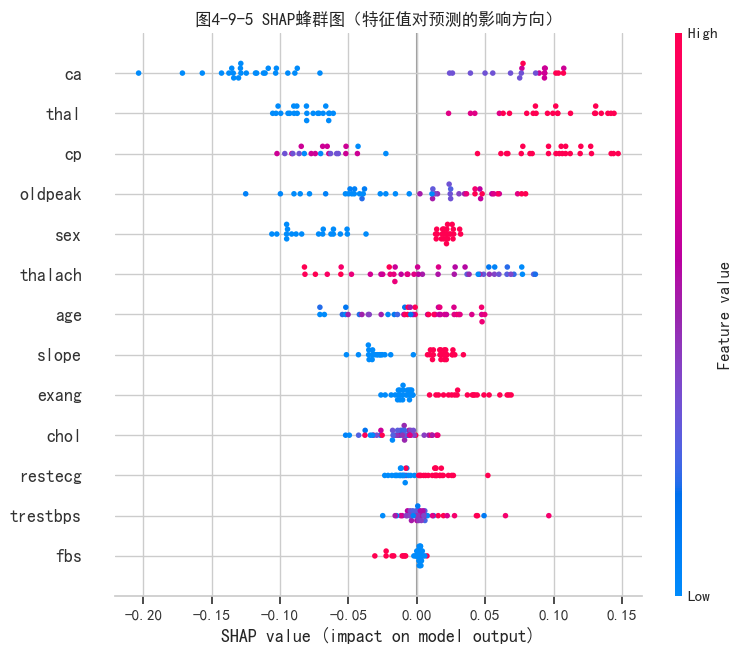

In [46]:
#4.9.4
import shap
import numpy as np
import matplotlib.pyplot as plt

# 设置绘图字体（解决中文显示问题，若环境不支持可注释掉）
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# 步骤一：初始化解释器 (Initialization)

# 1. 提取背景数据：使用kmeans聚类汇总训练集，减少计算量同时保留代表性
# 注意：.data 确保提取出数组格式，防止 InvalidMaskerError
X_train_summary = shap.kmeans(X_train_scaled, 10).data 

# 2. 创建 TreeExplainer 解释器
# rf 为之前训练好的随机森林模型
explainer = shap.TreeExplainer(rf, X_train_summary)

# 3. 选择待解释的数据（以验证集前45个样本为例）
X_test_sample = X_test_scaled[:45]

# 4. 计算 SHAP 值
# check_additivity=False 防止精度误差报错
shap_values_raw = explainer.shap_values(X_test_sample, check_additivity=False)

# 5. 提取正类（患病/Class 1）的 SHAP 值
# 逻辑：判断返回的是列表还是三维数组，确保提取到索引为1的类别
if isinstance(shap_values_raw, list):
    shap_values_class1 = shap_values_raw[1]
elif isinstance(shap_values_raw, np.ndarray) and len(shap_values_raw.shape) == 3:
    shap_values_class1 = shap_values_raw[:, :, 1]
else:
    shap_values_class1 = shap_values_raw

# ==========================================
# 步骤二：全局特征重要性（条形图）
# ==========================================
# 目的：展示哪些特征对模型预测的整体贡献最大
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_class1, X_test_sample, 
                  feature_names=feature_names, 
                  plot_type="bar",
                  show=False)
plt.title('图4-9-4 SHAP特征重要性排序')
plt.tight_layout()
plt.show()

# ==========================================
# 步骤三：特征影响方向分析（蜂群图）
# ==========================================
# 目的：展示特征数值的高低如何影响预测结果（正向或负向）
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_class1, X_test_sample, 
                  feature_names=feature_names,
                  show=False)
plt.title('图4-9-5 SHAP蜂群图（特征值对预测的影响方向）')
plt.tight_layout()
plt.show()
